# Análisis de Sincronización: Hilbert + Kuramoto + Joint Recurrence Plots (Lorenz Delayed)

Objetivo: Identificar el desfase temporal óptimo entre una serie temporal de Lorenz y su versión retrasada
usando:
1. Transformada de Hilbert + Parámetro de orden de Kuramoto (sincronización de fase)
2. Joint Recurrence Plots (sincronización de estados en espacio de fase)

---
**Criterio de desfase óptimo (Kuramoto):** Longest Continuous Sync Segment (`max_sustained_sec`)

El score de Kuramoto se calcula como la normalización del segmento continuo más largo
donde el parámetro de orden r > 0.7 (sincronización de fase fuerte).

**Criterio de desfase óptimo (JRP):** Score combinado RR × DET × max_diag

**Score combinado:** Media aritmética de ambos scores normalizados

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import hilbert
from scipy.ndimage import uniform_filter1d
from scipy.spatial.distance import pdist, squareform

from synch_analysis import LorenzDataSource, SynchronizationPipeline

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Generate delayed Lorenz time series using pipeline
# True delay: 150 steps at dt=0.01, sampling_rate=100 -> 1.5 seconds delay
lorenz_delayed = LorenzDataSource(
    a=10.0,
    b=28.0,
    c=8.0/3.0,
    dt=0.01,
    initial_values=[0.01, 0, 0.3],
    iterations=5000,
    variable='x',
    delay_steps=150,  # True delay to recover
    noise_std=0.05,   # Add some measurement noise
    sampling_rate=100.0
)

pipeline = SynchronizationPipeline(lorenz_delayed).run()

Loading data: Lorenz attractor: a=10.0, b=28.0, c=2.667, var=x, delay=150 steps, noise=0.05
  Signal A: Lorenz x (source) (5001 samples)
  Signal B: Lorenz x (delayed by 150 steps) (5001 samples)
Computing Hilbert transforms...
Computing Kuramoto order parameter...
  Mean R: 0.6011
  Sync ratio (R>0.8): 39.85%


In [3]:
# Extract signals from pipeline
signal_pair = pipeline.signal_pair
s1 = signal_pair.signal_a  # Source (reference)
s2 = signal_pair.signal_b  # Delayed version

# Normalize to [-1, 1] centered at 0
def normalize_zero_centered(x):
    x = np.asarray(x, dtype=float)
    x_centered = x - np.mean(x)
    max_abs = np.max(np.abs(x_centered))
    if max_abs > 0:
        return x_centered / max_abs
    return x_centered

s1_norm = normalize_zero_centered(s1)
s2_norm = normalize_zero_centered(s2)

time_axis = np.arange(len(s1_norm)) / signal_pair.sampling_rate

print(f'Signal length: {len(s1_norm)} samples')
print(f'Time duration: {time_axis[-1]:.1f} seconds')
print(f'Sampling rate: {signal_pair.sampling_rate} Hz')
print(f'True delay: 150 steps = {150/signal_pair.sampling_rate:.2f} seconds')

Signal length: 5001 samples
Time duration: 50.0 seconds
Sampling rate: 100.0 Hz
True delay: 150 steps = 1.50 seconds


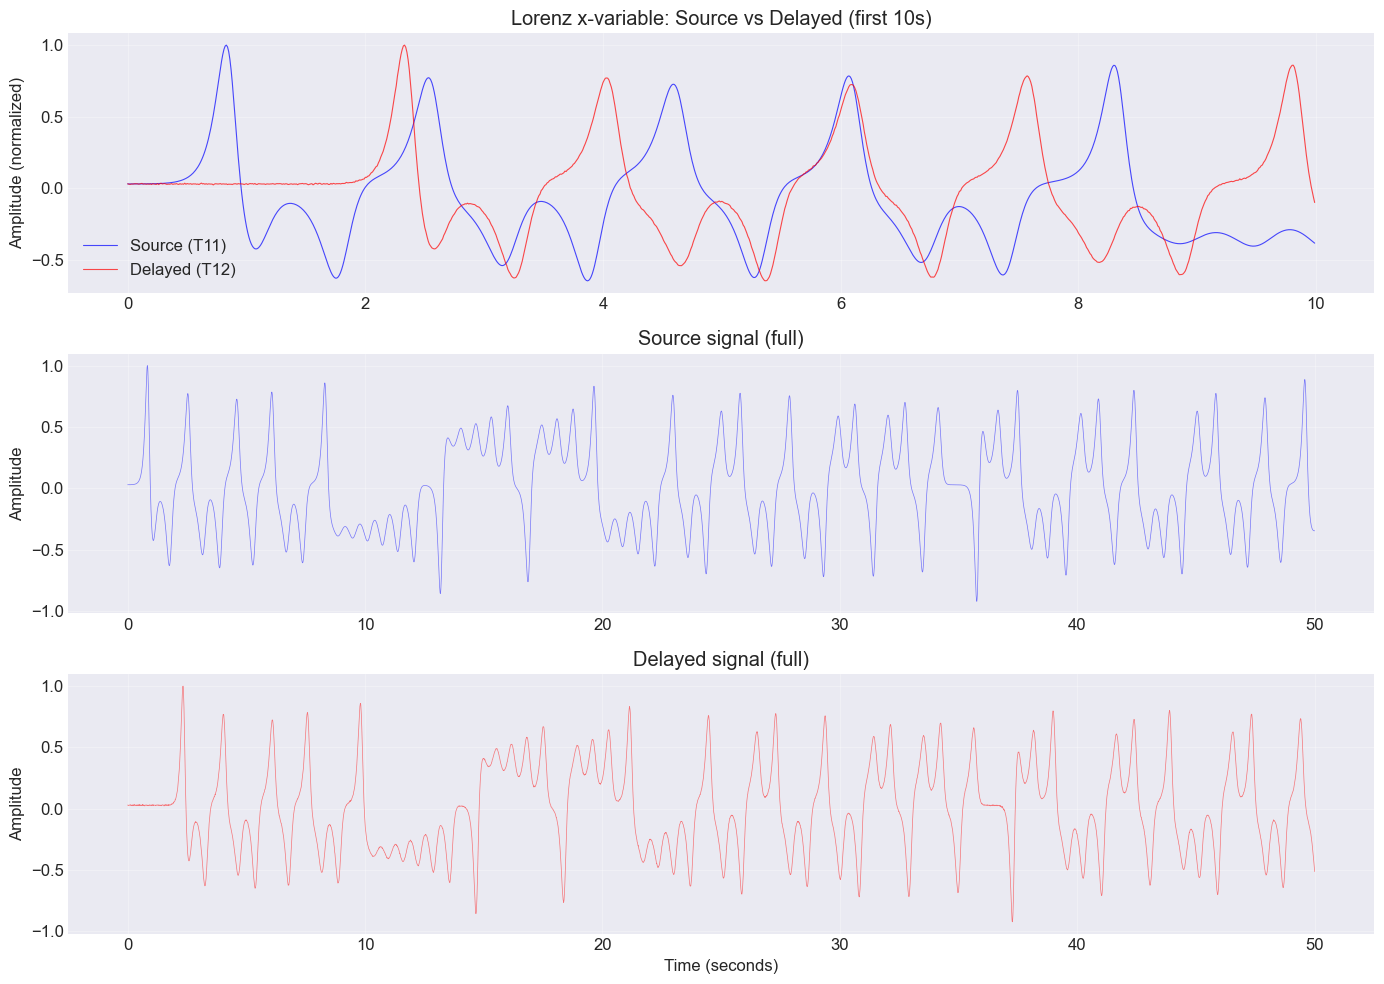

In [4]:
# Plot raw signals
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(time_axis[:1000], s1_norm[:1000], 'b-', label='Source (T11)', alpha=0.7, linewidth=0.8)
axes[0].plot(time_axis[:1000], s2_norm[:1000], 'r-', label='Delayed (T12)', alpha=0.7, linewidth=0.8)
axes[0].set_ylabel('Amplitude (normalized)')
axes[0].set_title('Lorenz x-variable: Source vs Delayed (first 10s)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_axis, s1_norm, 'b-', alpha=0.5, linewidth=0.5)
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Source signal (full)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_axis, s2_norm, 'r-', alpha=0.5, linewidth=0.5)
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_title('Delayed signal (full)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# --- HILBERT + KURAMOTO FUNCTIONS ---
def get_phase(signal):
    analytic = hilbert(signal)
    return np.angle(analytic)

def kuramoto_order_param(phi1, phi2):
    z = 0.5 * (np.exp(1j * phi1) + np.exp(1j * phi2))
    return np.abs(z)

# --- JOINT RECURRENCE PLOT FUNCTIONS ---
def embed_time_series(x, m=3, tau=1):
    """Time-delay embedding."""
    n = len(x)
    if n < (m - 1) * tau + 1:
        return np.array([])
    embedded = np.zeros((n - (m - 1) * tau, m))
    for i in range(m):
        embedded[:, i] = x[i * tau:n - (m - 1 - i) * tau]
    return embedded

def recurrence_plot(x, threshold=None, rate=0.05):
    """Compute recurrence plot for a single time series."""
    n = len(x)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    dists = squareform(pdist(x, metric='euclidean'))
    
    if threshold is None:
        # Fixed recurrence rate threshold
        flat_dists = dists[np.triu_indices(n, k=1)]
        threshold = np.percentile(flat_dists, rate * 100)
    
    rp = dists <= threshold
    return rp, threshold

def joint_recurrence_plot(rp1, rp2):
    """Compute Joint Recurrence Plot: JRP = RP1 AND RP2."""
    return rp1 & rp2

def jrp_rqa_metrics(jrp):
    """Compute RQA metrics from Joint Recurrence Plot."""
    n = jrp.shape[0]
    
    # Recurrence Rate (RR)
    rr = np.sum(jrp) / (n * n)
    
    # Determinism (DET) - fraction of recurrence points forming diagonal lines
    diag_lengths = []
    for offset in range(-n + 1, n):
        diag = np.diag(jrp, k=offset)
        if len(diag) < 2:
            continue
        in_line = False
        length = 0
        for val in diag:
            if val:
                if not in_line:
                    in_line = True
                    length = 1
                else:
                    length += 1
            else:
                if in_line and length >= 2:
                    diag_lengths.append(length)
                in_line = False
                length = 0
        if in_line and length >= 2:
            diag_lengths.append(length)
    
    if len(diag_lengths) > 0:
        det = np.sum(diag_lengths) / np.sum(jrp)
        max_diag = np.max(diag_lengths)
        mean_diag = np.mean(diag_lengths)
    else:
        det = 0
        max_diag = 0
        mean_diag = 0
    
    # Laminarity (LAM) - vertical lines
    vert_lengths = []
    for col in range(n):
        in_line = False
        length = 0
        for row in range(n):
            if jrp[row, col]:
                if not in_line:
                    in_line = True
                    length = 1
                else:
                    length += 1
            else:
                if in_line and length >= 2:
                    vert_lengths.append(length)
                in_line = False
                length = 0
        if in_line and length >= 2:
            vert_lengths.append(length)
    
    if len(vert_lengths) > 0:
        lam = np.sum(vert_lengths) / np.sum(jrp)
        max_vert = np.max(vert_lengths)
    else:
        lam = 0
        max_vert = 0
    
    return {
        'RR': rr,
        'DET': det,
        'LAM': lam,
        'max_diag': max_diag,
        'mean_diag': mean_diag,
        'max_vert': max_vert
    }

Embedded shapes: s1=(4999, 3), s2=(4999, 3)
Thresholds: th1=0.1245, th2=0.1219
JRP Metrics (lag=0): RR=0.0135, DET=0.9661, LAM=0.9815
  max_diag=4999, mean_diag=6.8, max_vert=60


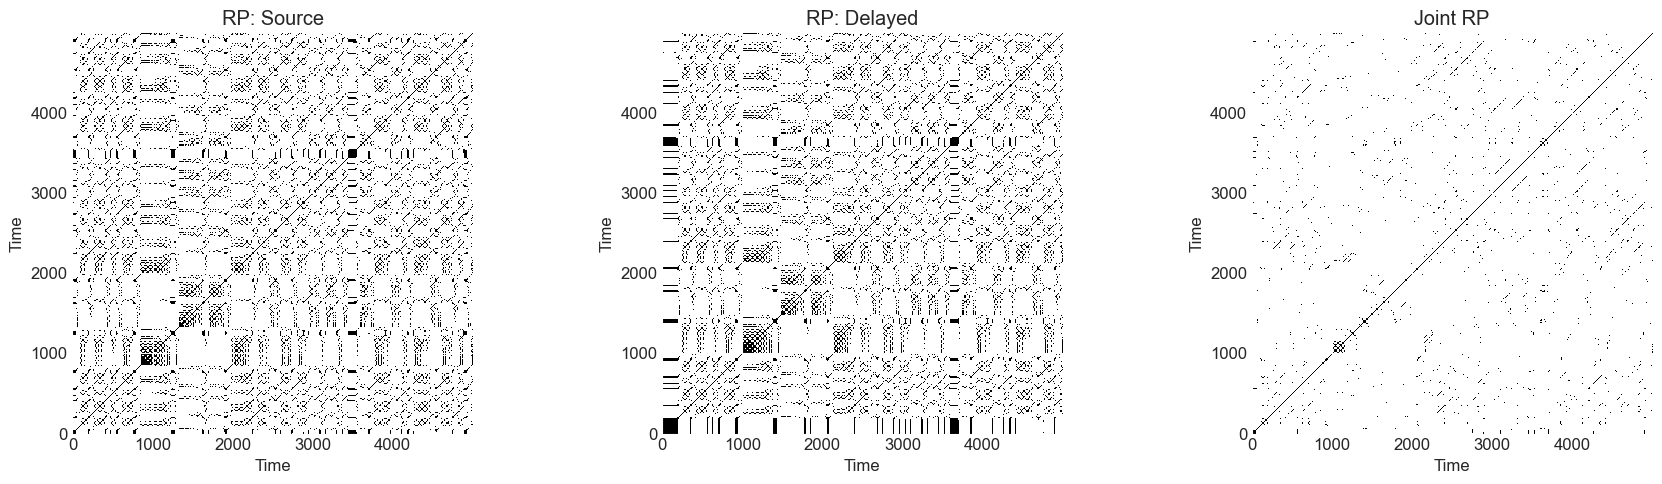

In [6]:
# Test JRP at lag=0
m, tau = 3, 1
s1_emb = embed_time_series(s1_norm, m=m, tau=tau)
s2_emb = embed_time_series(s2_norm, m=m, tau=tau)

print(f'Embedded shapes: s1={s1_emb.shape}, s2={s2_emb.shape}')

rp1, thresh1 = recurrence_plot(s1_emb, rate=0.1)
rp2, thresh2 = recurrence_plot(s2_emb, rate=0.1)
jrp = joint_recurrence_plot(rp1, rp2)

metrics = jrp_rqa_metrics(jrp)
print(f'Thresholds: th1={thresh1:.4f}, th2={thresh2:.4f}')
print(f'JRP Metrics (lag=0): RR={metrics["RR"]:.4f}, DET={metrics["DET"]:.4f}, LAM={metrics["LAM"]:.4f}')
print(f'  max_diag={metrics["max_diag"]}, mean_diag={metrics["mean_diag"]:.1f}, max_vert={metrics["max_vert"]}')

# Plot RPs and JRP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, rp, title in zip(axes, [rp1, rp2, jrp], ['RP: Source', 'RP: Delayed', 'Joint RP']):
    ax.imshow(rp.T, origin='lower', cmap='binary', aspect='equal', interpolation='nearest')
    ax.set_title(title)
    ax.set_xlabel('Time')
    ax.set_ylabel('Time')
plt.tight_layout()
plt.show()

In [7]:
# Sweep lags with both Kuramoto and JRP metrics
max_lag = 300  # steps (3 seconds at 100 Hz)
lag_step = 1
lags = np.arange(-max_lag, max_lag + 1, lag_step)

results = []

for lag in lags:
    # Shift s2
    if lag > 0:
        s2_shifted = np.concatenate([np.full(lag, np.nan), s2_norm[:-lag]])
    elif lag < 0:
        s2_shifted = np.concatenate([s2_norm[-lag:], np.full(-lag, np.nan)])
    else:
        s2_shifted = s2_norm.copy()
    s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
    
    # --- KURAMOTO ---
    phi1 = get_phase(s1_norm)
    phi2 = get_phase(s2_shifted)
    r = kuramoto_order_param(phi1, phi2)
    
    r_mean = np.mean(r)
    r_std = np.std(r)
    threshold = 0.7
    frac_above = np.mean(r > threshold)
    above = r > threshold
    max_sustained = 0
    current = 0
    for val in above:
        if val:
            current += 1
            max_sustained = max(max_sustained, current)
        else:
            current = 0
    
    # --- JRP (only compute at coarser resolution for speed) ---
    jrp_metrics = {'RR': 0, 'DET': 0, 'LAM': 0, 'max_diag': 0}
    if lag % 10 == 0:  # Compute JRP every 10 steps (0.1s)
        try:
            s2_emb = embed_time_series(s2_shifted, m=m, tau=tau)
            min_len = min(len(s1_emb), len(s2_emb))
            if min_len > 100:
                rp1, _ = recurrence_plot(s1_emb[:min_len], rate=0.1)
                rp2, _ = recurrence_plot(s2_emb[:min_len], rate=0.1)
                jrp = joint_recurrence_plot(rp1, rp2)
                jrp_metrics = jrp_rqa_metrics(jrp)
        except:
            pass
    
    results.append({
        'lag': lag,
        'lag_sec': lag / signal_pair.sampling_rate,
        'r_mean': r_mean,
        'r_std': r_std,
        'frac_above_07': frac_above,
        'max_sustained_sec': max_sustained / signal_pair.sampling_rate,
        'jrp_RR': jrp_metrics['RR'],
        'jrp_DET': jrp_metrics['DET'],
        'jrp_LAM': jrp_metrics['LAM'],
        'jrp_max_diag': jrp_metrics['max_diag']
    })
    
    if len(results) % 50 == 0:
        print(f'Processed {len(results)}/{len(lags)} lags...')

results_df = pd.DataFrame(results)
print('Done!')

Processed 50/601 lags...
Processed 100/601 lags...
Processed 150/601 lags...
Processed 200/601 lags...
Processed 250/601 lags...
Processed 300/601 lags...
Processed 350/601 lags...
Processed 400/601 lags...
Processed 450/601 lags...
Processed 500/601 lags...
Processed 550/601 lags...
Processed 600/601 lags...
Done!


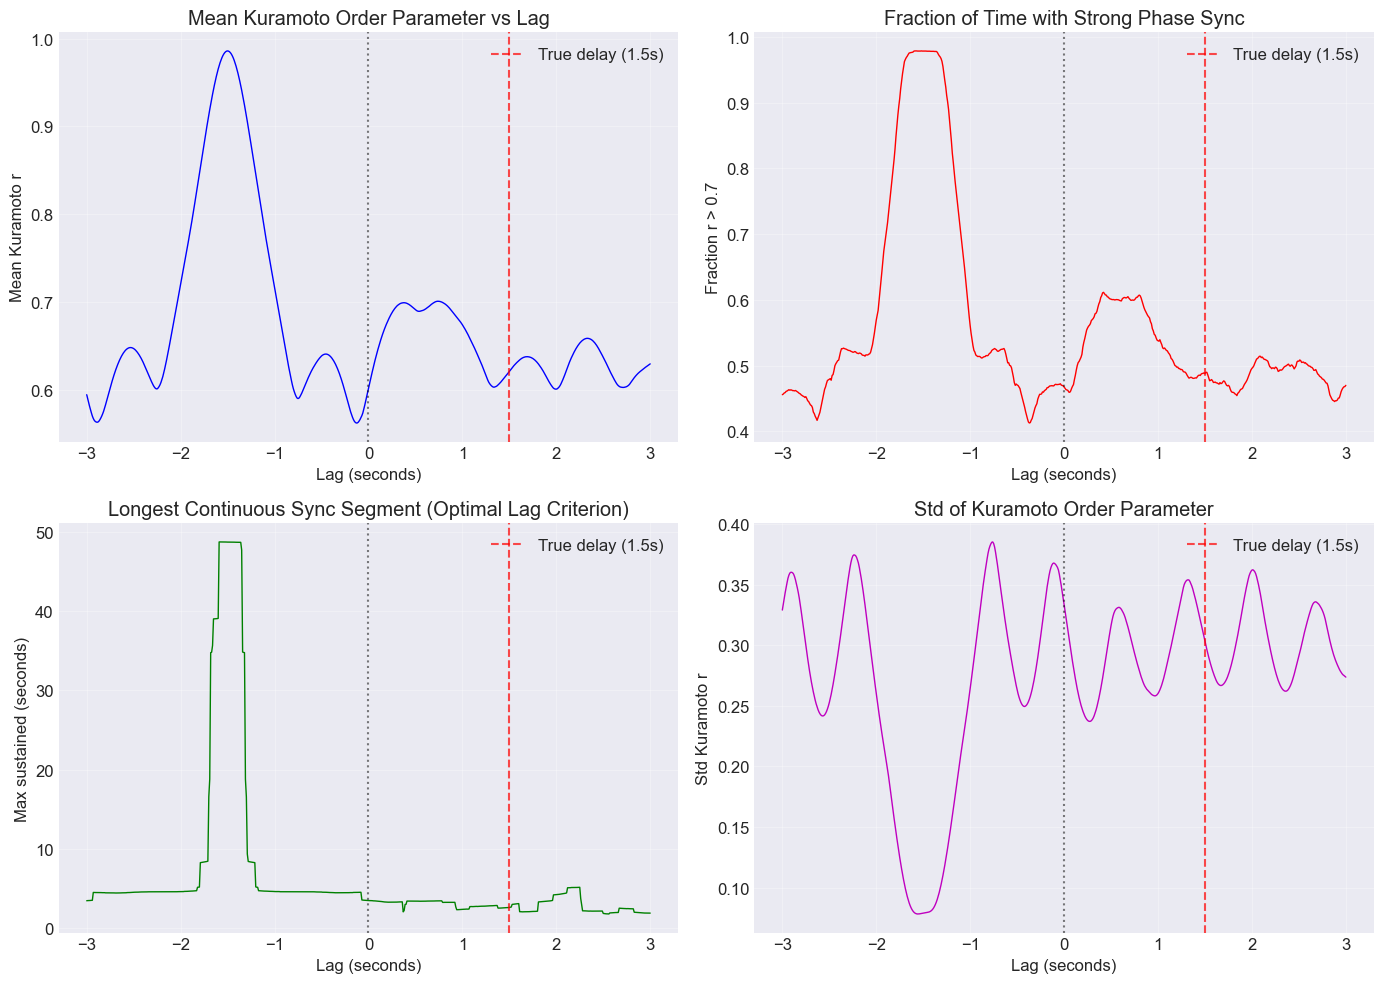

In [8]:
# Plot Kuramoto metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(results_df['lag_sec'], results_df['r_mean'], 'b-', linewidth=1)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Mean Kuramoto r')
axes[0, 0].set_title('Mean Kuramoto Order Parameter vs Lag')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[0, 0].legend()

axes[0, 1].plot(results_df['lag_sec'], results_df['frac_above_07'], 'r-', linewidth=1)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Fraction r > 0.7')
axes[0, 1].set_title('Fraction of Time with Strong Phase Sync')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[0, 1].legend()

axes[1, 0].plot(results_df['lag_sec'], results_df['max_sustained_sec'], 'g-', linewidth=1)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Max sustained (seconds)')
axes[1, 0].set_title('Longest Continuous Sync Segment (Optimal Lag Criterion)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[1, 0].legend()

axes[1, 1].plot(results_df['lag_sec'], results_df['r_std'], 'm-', linewidth=1)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Std Kuramoto r')
axes[1, 1].set_title('Std of Kuramoto Order Parameter')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

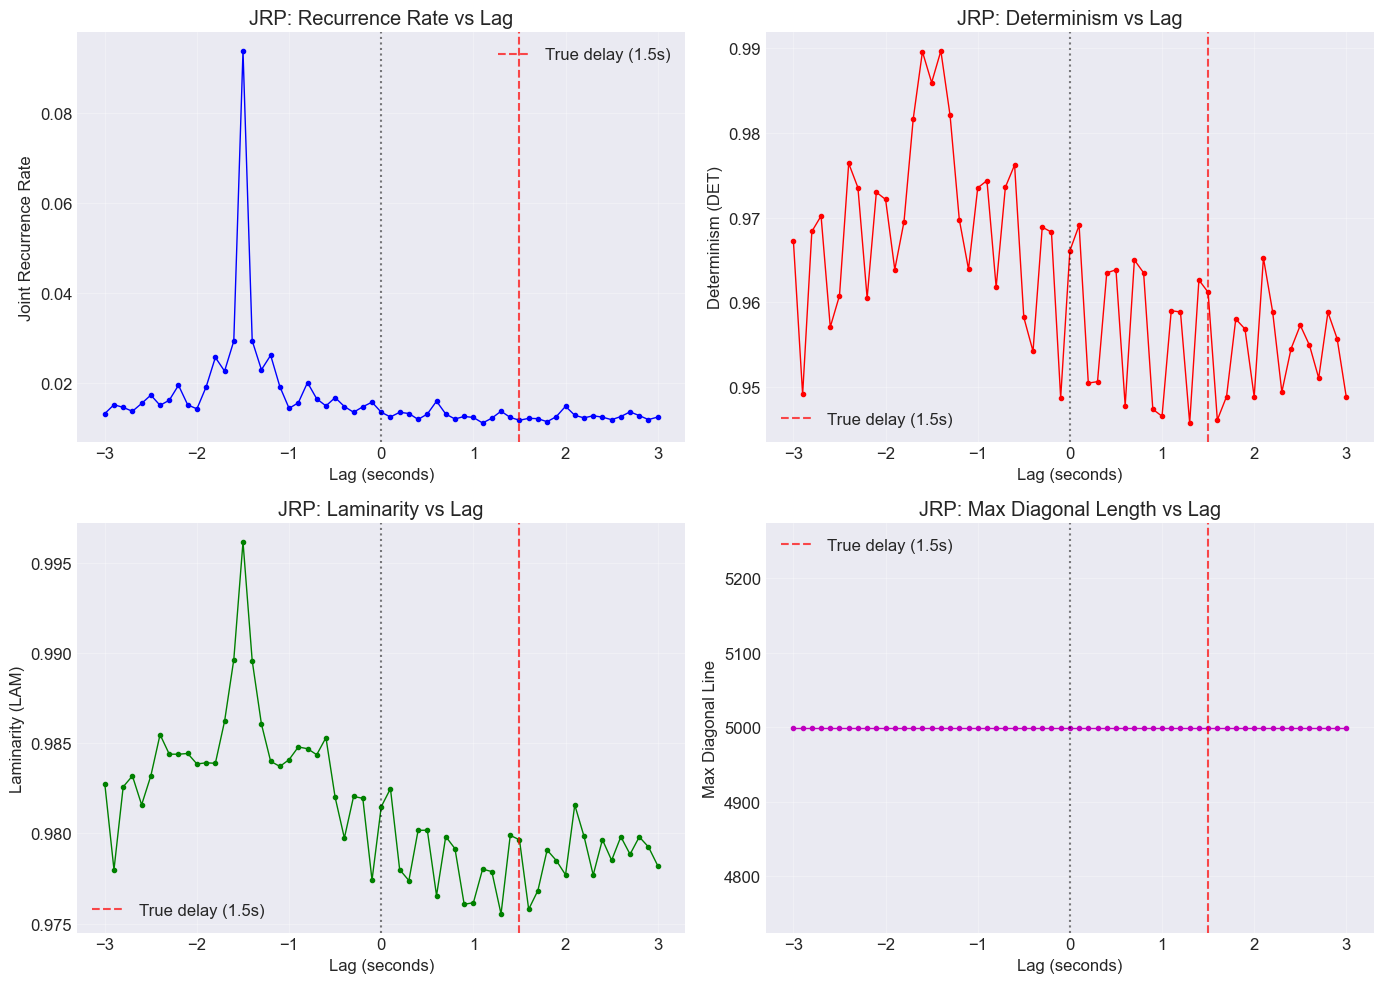

In [9]:
# Plot JRP metrics (only computed every 10 steps = 0.1s)
jrp_df = results_df[results_df['jrp_RR'] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(jrp_df['lag_sec'], jrp_df['jrp_RR'], 'b-o', linewidth=1, markersize=3)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Joint Recurrence Rate')
axes[0, 0].set_title('JRP: Recurrence Rate vs Lag')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[0, 0].legend()

axes[0, 1].plot(jrp_df['lag_sec'], jrp_df['jrp_DET'], 'r-o', linewidth=1, markersize=3)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Determinism (DET)')
axes[0, 1].set_title('JRP: Determinism vs Lag')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[0, 1].legend()

axes[1, 0].plot(jrp_df['lag_sec'], jrp_df['jrp_LAM'], 'g-o', linewidth=1, markersize=3)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Laminarity (LAM)')
axes[1, 0].set_title('JRP: Laminarity vs Lag')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[1, 0].legend()

axes[1, 1].plot(jrp_df['lag_sec'], jrp_df['jrp_max_diag'], 'm-o', linewidth=1, markersize=3)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Max Diagonal Line')
axes[1, 1].set_title('JRP: Max Diagonal Length vs Lag')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Combined analysis: Find optimal lag from both methods
# KURAMOTO: Use 'Longest continuous sync segment' (max_sustained_sec) as criterion
# JRP: Use combined JRP score (RR * DET * max_diag)
def normalize(series):
    min_v, max_v = series.min(), series.max()
    if max_v > min_v:
        return (series - min_v) / (max_v - min_v)
    return series * 0

# Kuramoto score = max_sustained_sec (longest continuous sync segment)
results_df['kuramoto_score'] = normalize(results_df['max_sustained_sec'])

# JRP score = normalized product of RR, DET, max_diag
results_df['jrp_score'] = normalize(results_df['jrp_RR']) * normalize(results_df['jrp_DET']) * normalize(results_df['jrp_max_diag'])
results_df['combined_score'] = (results_df['kuramoto_score'] + results_df['jrp_score']) / 2

print('=== Top 10 by Kuramoto Score (Longest Continuous Sync Segment) ===')
print(results_df.nlargest(10, 'kuramoto_score')[['lag_sec', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'kuramoto_score']].to_string(index=False))

print('\n=== Top 10 by JRP Score (where computed) ===')
jrp_scored = results_df[results_df['jrp_RR'] > 0]
print(jrp_scored.nlargest(10, 'jrp_score')[['lag_sec', 'jrp_RR', 'jrp_DET', 'jrp_max_diag', 'jrp_score']].to_string(index=False))

print('\n=== Top 10 by Combined Score ===')
print(results_df.nlargest(10, 'combined_score')[['lag_sec', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'jrp_RR', 'jrp_DET', 'combined_score']].to_string(index=False))

=== Top 10 by Kuramoto Score (Longest Continuous Sync Segment) ===
 lag_sec   r_mean  frac_above_07  max_sustained_sec  kuramoto_score
   -1.59 0.969095       0.978404              48.75        1.000000
   -1.58 0.972528       0.978404              48.75        1.000000
   -1.57 0.975603       0.978404              48.75        1.000000
   -1.56 0.978304       0.978204              48.74        0.999787
   -1.55 0.980616       0.978204              48.74        0.999787
   -1.54 0.982526       0.978204              48.74        0.999787
   -1.53 0.984022       0.978204              48.74        0.999787
   -1.52 0.985094       0.978404              48.74        0.999787
   -1.51 0.985734       0.978204              48.73        0.999574
   -1.50 0.985937       0.978204              48.73        0.999574

=== Top 10 by JRP Score (where computed) ===
 lag_sec   jrp_RR  jrp_DET  jrp_max_diag  jrp_score
    -1.5 0.093787 0.985934          4999   0.996231
    -1.4 0.029391 0.989663         

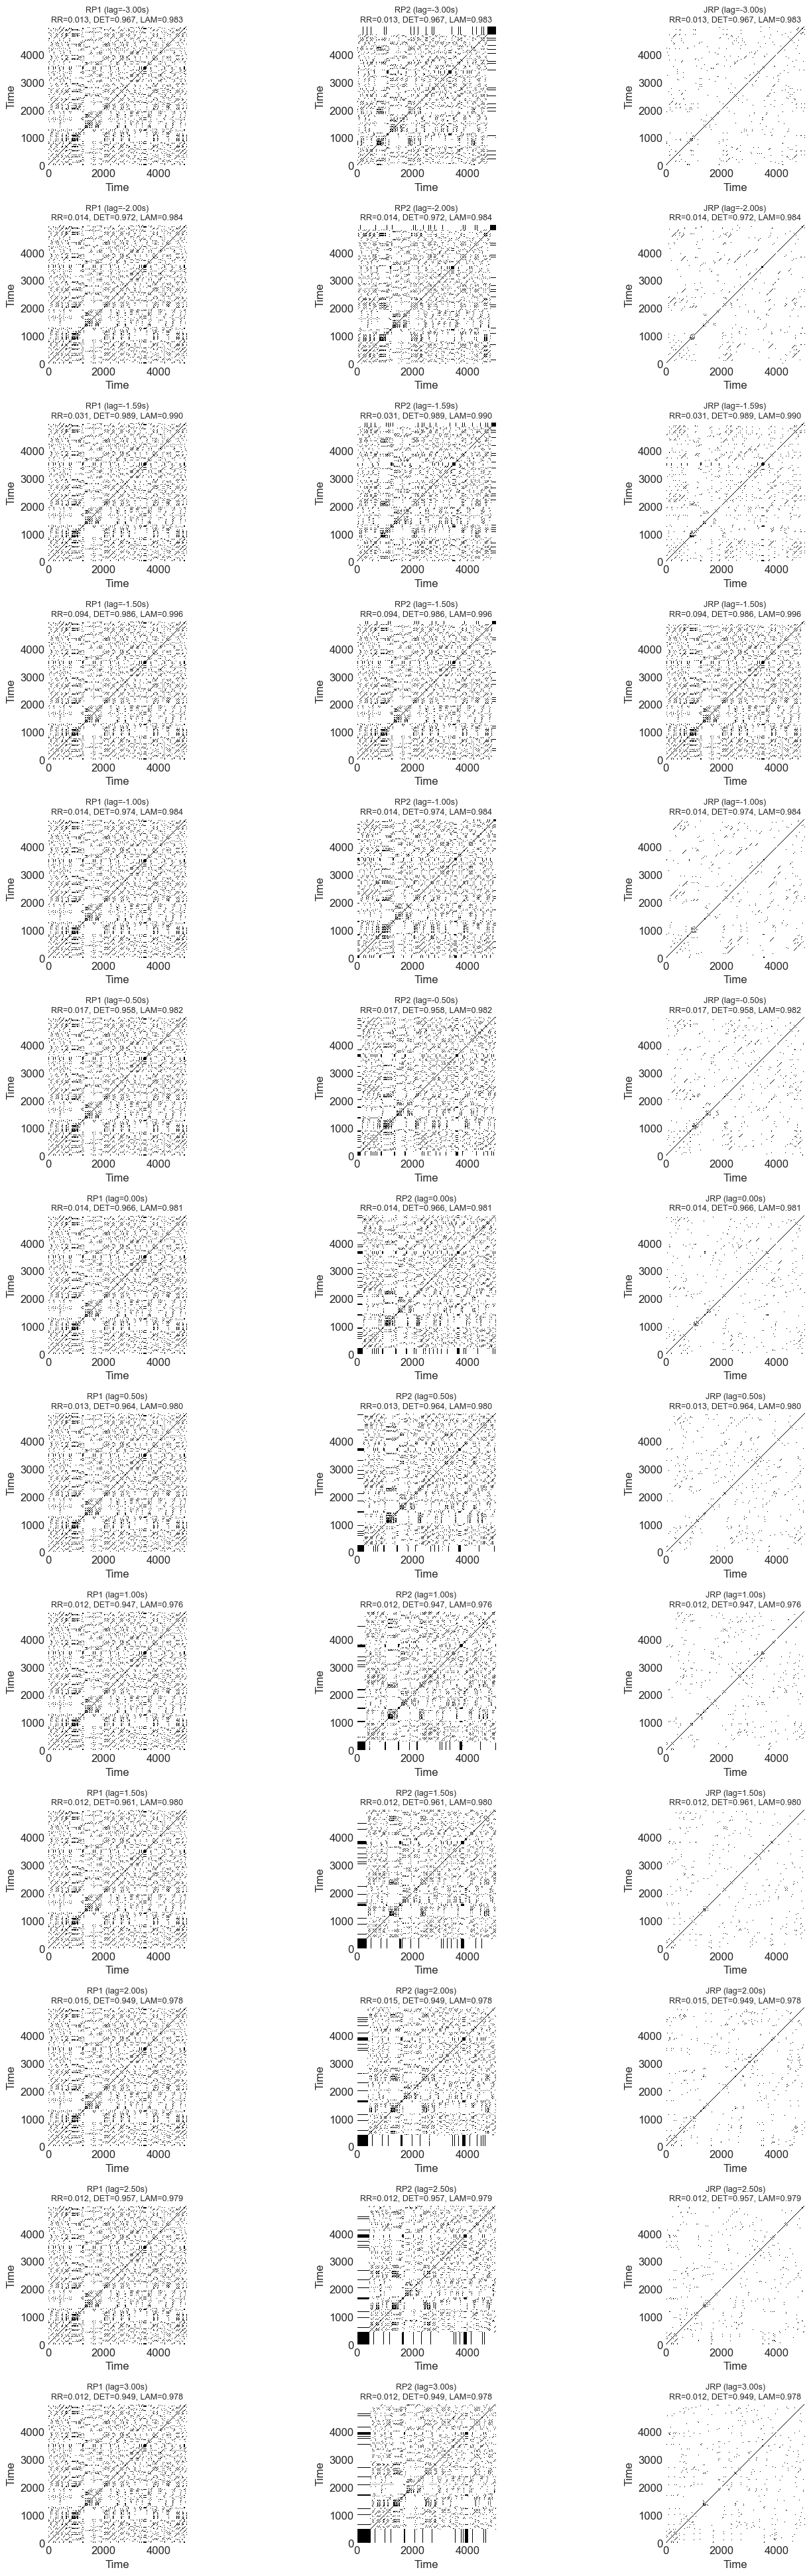

In [11]:
# Detailed JRP visualization at key lags
best_kuramoto_lag = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_jrp_lag = int(jrp_scored.loc[jrp_scored['jrp_score'].idxmax(), 'lag']) if len(jrp_scored) > 0 else 0
true_delay_lag = 150

key_lags = [-300, -200, -100, -50, 0, 50, 100, 150, 200, 250, 300, best_kuramoto_lag, best_jrp_lag]
key_lags = sorted(set([l for l in key_lags if -max_lag <= l <= max_lag]))

fig, axes = plt.subplots(len(key_lags), 3, figsize=(15, 3*len(key_lags)))
if len(key_lags) == 1:
    axes = axes.reshape(1, -1)

for idx, lag in enumerate(key_lags):
    if lag > 0:
        s2_shifted = np.concatenate([np.full(lag, np.nan), s2_norm[:-lag]])
    elif lag < 0:
        s2_shifted = np.concatenate([s2_norm[-lag:], np.full(-lag, np.nan)])
    else:
        s2_shifted = s2_norm.copy()
    s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
    
    s1_emb = embed_time_series(s1_norm, m=m, tau=tau)
    s2_emb = embed_time_series(s2_shifted, m=m, tau=tau)
    min_len = min(len(s1_emb), len(s2_emb))
    
    if min_len > 50:
        rp1, _ = recurrence_plot(s1_emb[:min_len], rate=0.1)
        rp2, _ = recurrence_plot(s2_emb[:min_len], rate=0.1)
        jrp = joint_recurrence_plot(rp1, rp2)
        metrics = jrp_rqa_metrics(jrp)
        
        for ax, rp, title in zip(axes[idx], [rp1, rp2, jrp], 
                                  [f'RP1 (lag={lag/100:.2f}s)', f'RP2 (lag={lag/100:.2f}s)', f'JRP (lag={lag/100:.2f}s)']):
            im = ax.imshow(rp.T, origin='lower', cmap='binary', aspect='equal', interpolation='nearest')
            ax.set_title(f'{title}\nRR={metrics["RR"]:.3f}, DET={metrics["DET"]:.3f}, LAM={metrics["LAM"]:.3f}', fontsize=9)
            ax.set_xlabel('Time')
            ax.set_ylabel('Time')
    else:
        for ax in axes[idx]:
            ax.text(0.5, 0.5, 'Too short', ha='center', va='center')

plt.tight_layout()
plt.show()

In [12]:
# JRP at best Kuramoto lag (max_sustained)
best_kuramoto_lag = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])

for lag in [best_kuramoto_lag, 150]:
    if lag > 0:
        s2_shifted = np.concatenate([np.full(lag, np.nan), s2_norm[:-lag]])
    elif lag < 0:
        s2_shifted = np.concatenate([s2_norm[-lag:], np.full(-lag, np.nan)])
    else:
        s2_shifted = s2_norm.copy()
    s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
    
    s1_emb = embed_time_series(s1_norm, m=m, tau=tau)
    s2_emb = embed_time_series(s2_shifted, m=m, tau=tau)
    min_len = min(len(s1_emb), len(s2_emb))
    
    if min_len > 50:
        rp1, _ = recurrence_plot(s1_emb[:min_len], rate=0.05)
        rp2, _ = recurrence_plot(s2_emb[:min_len], rate=0.05)
        jrp = joint_recurrence_plot(rp1, rp2)
        metrics = jrp_rqa_metrics(jrp)
        
        print(f'\n=== Lag = {lag} steps ({lag/100:.2f}s) ===')
        print(f'  JRP: RR={metrics["RR"]:.4f}, DET={metrics["DET"]:.4f}, LAM={metrics["LAM"]:.4f}')
        print(f'  max_diag={metrics["max_diag"]}, mean_diag={metrics["mean_diag"]:.1f}, max_vert={metrics["max_vert"]}')


=== Lag = -159 steps (-1.59s) ===
  JRP: RR=0.0122, DET=0.9847, LAM=0.9667
  max_diag=4999, mean_diag=12.9, max_vert=98

=== Lag = 150 steps (1.50s) ===
  JRP: RR=0.0037, DET=0.9238, LAM=0.9390
  max_diag=4999, mean_diag=5.4, max_vert=55


In [13]:
# Save results
results_df.to_parquet('../data/kuramoto_jrp_lag_sweep_lorenz_delayed.parquet')
print('Saved lag sweep results to ../data/kuramoto_jrp_lag_sweep_lorenz_delayed.parquet')

# Summary
best_kuramoto = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_kuramoto_sustained = results_df.loc[results_df['kuramoto_score'].idxmax(), 'max_sustained_sec']
best_jrp = int(jrp_scored.loc[jrp_scored['jrp_score'].idxmax(), 'lag']) if len(jrp_scored) > 0 else 'N/A'
best_combined = int(results_df.loc[results_df['combined_score'].idxmax(), 'lag'])

print(f'\n=== FINAL SUMMARY ===')
print(f'True delay:                                         150 steps (1.50s)')
print(f'Best lag (Kuramoto - Longest Continuous Sync):     {best_kuramoto} steps ({best_kuramoto/100:.2f}s)  [max_sustained={best_kuramoto_sustained:.2f}s]')
print(f'Best lag (JRP state sync):                         {best_jrp} steps ({best_jrp/100:.2f}s)')
print(f'Best lag (Combined):                               {best_combined} steps ({best_combined/100:.2f}s)')

error_kuramoto = abs(best_kuramoto - 150) / 100
error_jrp = abs(best_jrp - 150) / 100 if best_jrp != 'N/A' else 'N/A'
error_combined = abs(best_combined - 150) / 100
print(f'\nErrors vs true delay:')
print(f'  Kuramoto:  {error_kuramoto:.2f}s')
print(f'  JRP:       {error_jrp:.2f}s' if error_jrp != 'N/A' else '  JRP:       N/A')
print(f'  Combined:  {error_combined:.2f}s')

Saved lag sweep results to ../data/kuramoto_jrp_lag_sweep_lorenz_delayed.parquet

=== FINAL SUMMARY ===
True delay:                                         150 steps (1.50s)
Best lag (Kuramoto - Longest Continuous Sync):     -159 steps (-1.59s)  [max_sustained=48.75s]
Best lag (JRP state sync):                         -150 steps (-1.50s)
Best lag (Combined):                               -150 steps (-1.50s)

Errors vs true delay:
  Kuramoto:  3.09s
  JRP:       3.00s
  Combined:  3.00s
